# Stage 1 - Step 5: Pulling it all together

This is the notebook that actually produces what we present. Everything here reads
from files notebooks 2-4 already created - nothing gets re-extracted or re-trained
except for two small linear probes we retrain just to get per-image predictions for
the confusion matrices (accuracy alone doesn't tell you *which* classes get confused
with which).

The 5 required deliverables, in order:
1. Accuracy table (every dataset x encoder x K x baseline)
2. Accuracy vs. training-size plot with error bars
3. Training/val loss curves (already have these from notebook 3, just re-plotting
   them here so everything lives in one final notebook)
4. Confusion matrices (one per dataset)
5. PCA/t-SNE feature visualization with prototypes overlaid

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_ROOT = '/content/drive/MyDrive/cvlab_stage1'
CACHE_ROOT = os.path.join(PROJECT_ROOT, 'features')
RESULTS_ROOT = os.path.join(PROJECT_ROOT, 'results')
FIGURES_ROOT = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(FIGURES_ROOT, exist_ok=True)

print('project root:', PROJECT_ROOT)

project root: /content/drive/MyDrive/cvlab_stage1


In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

def load_features(encoder, dataset, split):
    path = os.path.join(CACHE_ROOT, f'{encoder}_{dataset}_{split}.pt')
    d = torch.load(path)
    return d['features'], d['labels'], d['classes']

combos = [('resnet18', 'dtd'), ('resnet18', 'aircraft'), ('dinov2', 'aircraft')]

## 1. Accuracy table

Loading both result CSVs and building one combined table: mean +/- std over the 3
seeds for every (encoder, dataset, K, method) combination. For the prototype method's
full setting, there's only 1 run (no seed to vary), so std is just left blank there
rather than shown as a meaningless NaN.

In [4]:
lp_df = pd.read_csv(os.path.join(RESULTS_ROOT, 'linear_probe_results.csv'))
lp_df['method'] = 'linear_probe'
proto_df = pd.read_csv(os.path.join(RESULTS_ROOT, 'prototype_results.csv'))
proto_df['method'] = 'prototype'

all_df = pd.concat([lp_df[['encoder','dataset','K','method','test_acc']],
                     proto_df[['encoder','dataset','K','method','test_acc']]], ignore_index=True)

summary = all_df.groupby(['encoder','dataset','K','method'])['test_acc'].agg(['mean','std','count']).reset_index()
summary['mean'] = (summary['mean'] * 100).round(2)
summary['std'] = (summary['std'] * 100).round(2)

def format_row(r):
    if r['count'] <= 1 or pd.isna(r['std']):
        return f"{r['mean']:.2f} (1 run)"
    return f"{r['mean']:.2f} +/- {r['std']:.2f}"

summary['accuracy (%)'] = summary.apply(format_row, axis=1)
display_table = summary[['encoder','dataset','K','method','accuracy (%)']].sort_values(
    ['dataset','encoder','method','K'])

display_table.to_csv(os.path.join(RESULTS_ROOT, 'final_accuracy_table.csv'), index=False)
print('saved final_accuracy_table.csv')
display_table

saved final_accuracy_table.csv


,encoder,dataset,K,method,accuracy (%)
0,dinov2,aircraft,10,linear_probe,51.91 +/- 1.33
2,dinov2,aircraft,5,linear_probe,38.31 +/- 2.18
4,dinov2,aircraft,full,linear_probe,67.06 +/- 0.11
1,dinov2,aircraft,10,prototype,27.60 +/- 0.78
3,dinov2,aircraft,5,prototype,23.88 +/- 0.60
5,dinov2,aircraft,full,prototype,34.23 (1 run)
6,resnet18,aircraft,10,linear_probe,27.55 +/- 0.77
8,resnet18,aircraft,5,linear_probe,20.15 +/- 0.09
10,resnet18,aircraft,full,linear_probe,36.99 +/- 0.41
7,resnet18,aircraft,10,prototype,20.00 +/- 0.67


## 2. Accuracy vs. training-size plot

One subplot per (encoder, dataset) combination, both methods (linear probe and
prototype) overlaid, with error bars showing std across the 3 seeds. We're using
categorical x-positions (5-shot / 10-shot / full) rather than a numeric x-axis,
since "full" means a different actual image count per dataset - plotting it as a
number wouldn't be comparable across datasets anyway.

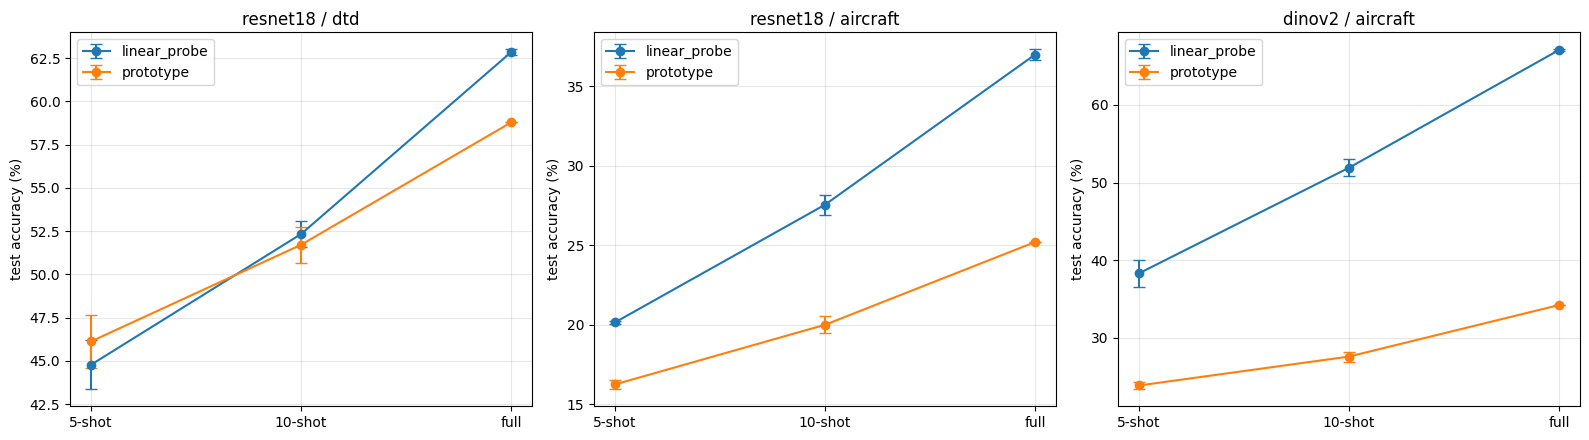

saved accuracy_vs_k.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_labels = ['5-shot', '10-shot', 'full']
x_pos = [0, 1, 2]

for ax, (encoder, dataset) in zip(axes, combos):
    for method, df, color in [('linear_probe', lp_df, 'tab:blue'), ('prototype', proto_df, 'tab:orange')]:
        sub = df[(df.encoder == encoder) & (df.dataset == dataset)]
        means, stds = [], []
        for k in ['5', '10', 'full']:
            vals = sub[sub.K == k]['test_acc'].values
            means.append(vals.mean() * 100)
            stds.append(vals.std() * 100 if len(vals) > 1 else 0)
        ax.errorbar(x_pos, means, yerr=stds, marker='o', capsize=4, label=method, color=color)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('test accuracy (%)')
    ax.set_title(f'{encoder} / {dataset}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_ROOT, 'accuracy_vs_k.png'), dpi=150)
plt.show()
print('saved accuracy_vs_k.png')

## 3. Training / validation loss curves

Re-plotting the representative 10-shot curves notebook 3 saved, just so this one
notebook has everything self-contained for the presentation.

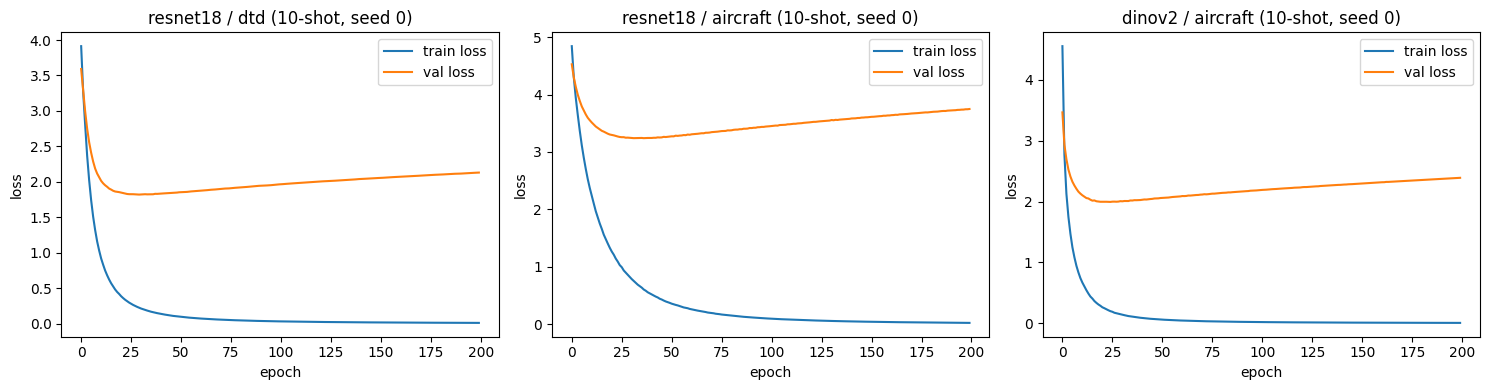

saved loss_curves.png


In [6]:
with open(os.path.join(RESULTS_ROOT, 'linear_probe_curves.json')) as f:
    curve_data = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (encoder, dataset) in zip(axes, combos):
    c = curve_data[f'{encoder}_{dataset}']
    ax.plot(c['train_loss'], label='train loss')
    ax.plot(c['val_loss'], label='val loss')
    ax.set_title(f'{encoder} / {dataset} (10-shot, seed 0)')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_ROOT, 'loss_curves.png'), dpi=150)
plt.show()
print('saved loss_curves.png')

## 4. Confusion matrices

The assignment wants one row-normalized confusion matrix per dataset, for whichever
setting is most useful for understanding the main classification errors. We're using
the **full-data linear probe** (best-performing setting we have) for each dataset:
- **DTD**: ResNet-18 (our only encoder on this dataset)
- **Aircraft**: DINOv2 (our best-performing encoder on this dataset - most
  informative choice, since it shows what's still being confused even by our
  strongest model)

Neither notebook 3 nor 4 saved per-image predictions (only accuracy numbers), so we
retrain just these 2 specific settings here to get predictions to build the matrix
from. This is the exact same training function from notebook 3, just reused.

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def train_linear_probe_get_preds(train_feats, train_labels, val_feats, val_labels, test_feats, test_labels,
                                  num_classes, seed=0, max_epochs=200, lr=1e-3, weight_decay=1e-4, batch_size=64):
    torch.manual_seed(seed)
    feat_dim = train_feats.shape[1]
    model = nn.Linear(feat_dim, num_classes).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_feats_d, train_labels_d = train_feats.to(device), train_labels.to(device)
    val_feats_d, val_labels_d = val_feats.to(device), val_labels.to(device)
    test_feats_d = test_feats.to(device)

    train_ds = torch.utils.data.TensorDataset(train_feats_d, train_labels_d)
    gen = torch.Generator().manual_seed(seed)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=gen)

    best_val_acc, best_state = -1.0, None
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            val_acc = (model(val_feats_d).argmax(1) == val_labels_d).float().mean().item()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_preds = model(test_feats_d).argmax(1).cpu()
    return test_preds

representative_settings = [('resnet18', 'dtd'), ('dinov2', 'aircraft')]
predictions = {}

for encoder, dataset in representative_settings:
    print(f'retraining full-data linear probe: {encoder} / {dataset}')
    train_feats, train_labels, classes = load_features(encoder, dataset, 'train')
    val_feats, val_labels, _ = load_features(encoder, dataset, 'val')
    test_feats, test_labels, _ = load_features(encoder, dataset, 'test')
    preds = train_linear_probe_get_preds(train_feats, train_labels, val_feats, val_labels,
                                          test_feats, test_labels, num_classes=len(classes))
    predictions[f'{encoder}_{dataset}'] = {'preds': preds, 'labels': test_labels, 'classes': classes}
    acc = (preds == test_labels).float().mean().item()
    print(f'  test_acc={acc:.4f} (should roughly match notebook 3\'s full-data result)')

retraining full-data linear probe: resnet18 / dtd
  test_acc=0.6298 (should roughly match notebook 3's full-data result)
retraining full-data linear probe: dinov2 / aircraft
  test_acc=0.6703 (should roughly match notebook 3's full-data result)


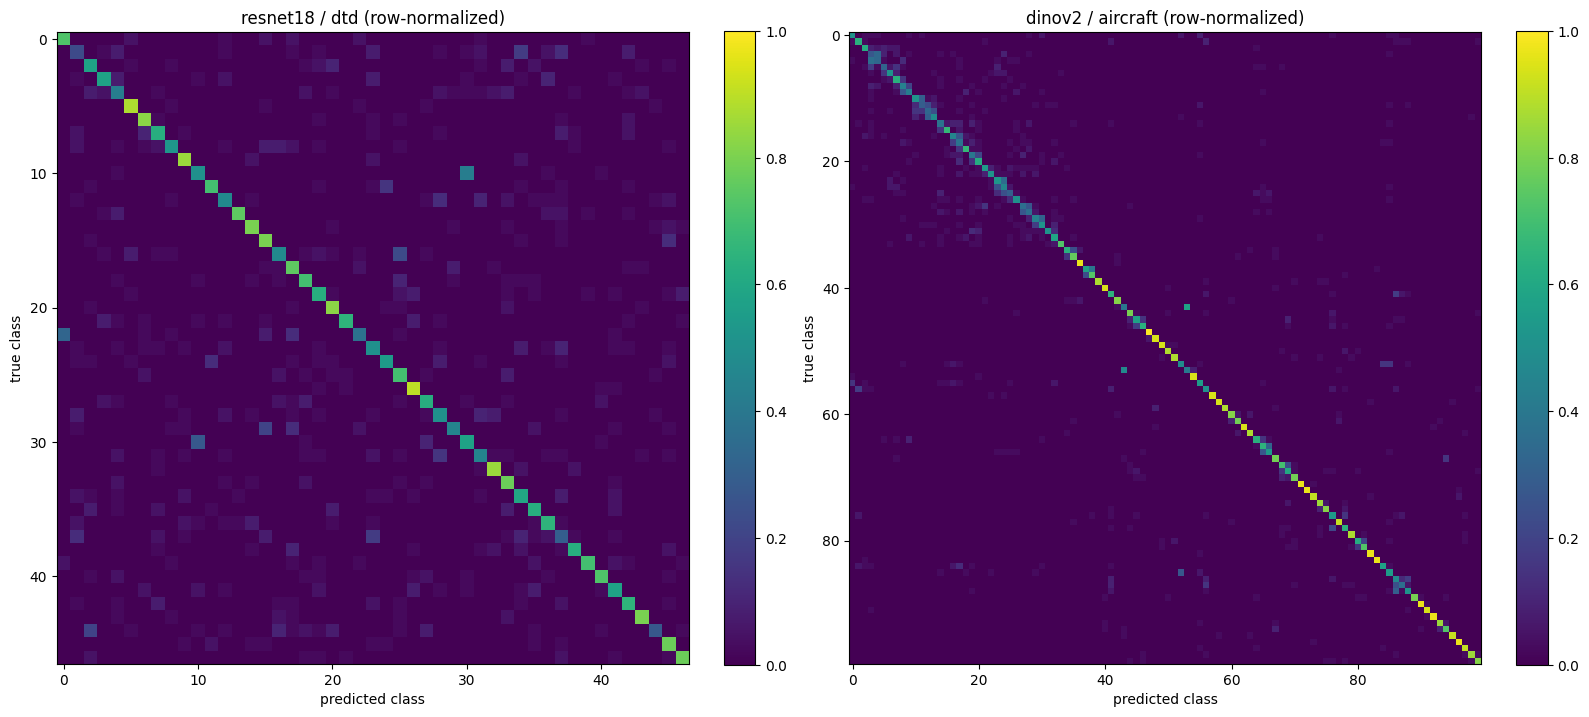

saved confusion_matrices.png

Note: with 47-100 classes, individual cell numbers aren't meant to be readable -
what matters is the diagonal being bright (correct predictions) and spotting any
bright off-diagonal spots (systematic confusions between specific class pairs).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (encoder, dataset) in zip(axes, representative_settings):
    d = predictions[f'{encoder}_{dataset}']
    cm = confusion_matrix(d['labels'].numpy(), d['preds'].numpy(), normalize='true')
    im = ax.imshow(cm, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'{encoder} / {dataset} (row-normalized)')
    ax.set_xlabel('predicted class')
    ax.set_ylabel('true class')
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_ROOT, 'confusion_matrices.png'), dpi=150)
plt.show()
print('saved confusion_matrices.png')
print()
print('Note: with 47-100 classes, individual cell numbers aren\'t meant to be readable -')
print('what matters is the diagonal being bright (correct predictions) and spotting any')
print('bright off-diagonal spots (systematic confusions between specific class pairs).')

## 5. Feature visualization (t-SNE, with prototypes overlaid)

Last required deliverable. For each dataset we pick a fixed, readable set of 10
classes (just the first 10 by class index - arbitrary but deterministic, so it's
reproducible), take all their test images, and project the frozen features down to
2D with t-SNE. We plot the prototype for each class as a big star in the same color
as its test points, so you can see whether "the average of a class" actually sits
near the middle of that class's cloud of test images - a good visual check on
whether the prototype method's assumption (that averaging is meaningful) actually
holds up for a given dataset.

For Aircraft, we do this **twice** - once for ResNet-18, once for DINOv2 - using the
exact same 10 classes, the exact same test images, and the exact same colors, so the
two plots are a fair side-by-side comparison of what each encoder's feature space
looks like for the same data.

Important, and worth saying out loud in the presentation: this is a **qualitative**
picture, not a performance measurement - t-SNE distorts distances, so "classes look
separated here" doesn't directly translate into "this encoder scores higher."

In [9]:
full_prototypes = torch.load(os.path.join(CACHE_ROOT, 'full_prototypes.pt'))

def l2_normalize(x, dim=1, eps=1e-8):
    return x / x.norm(dim=dim, keepdim=True).clamp(min=eps)

def plot_feature_viz(ax, test_feats, test_labels, prototypes, classes, selected_class_idxs, title):
    mask = np.isin(test_labels.numpy(), selected_class_idxs)
    feats_sel = test_feats[mask].numpy()
    labels_sel = test_labels[mask].numpy()
    proto_sel = prototypes[selected_class_idxs].numpy()

    combined = np.concatenate([feats_sel, proto_sel], axis=0)
    perplexity = min(30, feats_sel.shape[0] - 1)
    proj = TSNE(n_components=2, random_state=0, perplexity=perplexity, init='pca').fit_transform(combined)
    n_test = feats_sel.shape[0]
    test_proj, proto_proj = proj[:n_test], proj[n_test:]

    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for i, c in enumerate(selected_class_idxs):
        m = labels_sel == c
        label_name = classes[c][:20]  # truncate long aircraft variant names for the legend
        ax.scatter(test_proj[m, 0], test_proj[m, 1], color=colors[i], alpha=0.6, s=25, label=label_name)
        ax.scatter(proto_proj[i, 0], proto_proj[i, 1], color=colors[i], marker='*',
                   s=350, edgecolor='black', linewidth=1.2, zorder=5)
    ax.set_title(title)
    ax.legend(fontsize=6, loc='best', ncol=1)
    ax.set_xticks([]); ax.set_yticks([])

SELECTED_CLASSES = list(range(10))

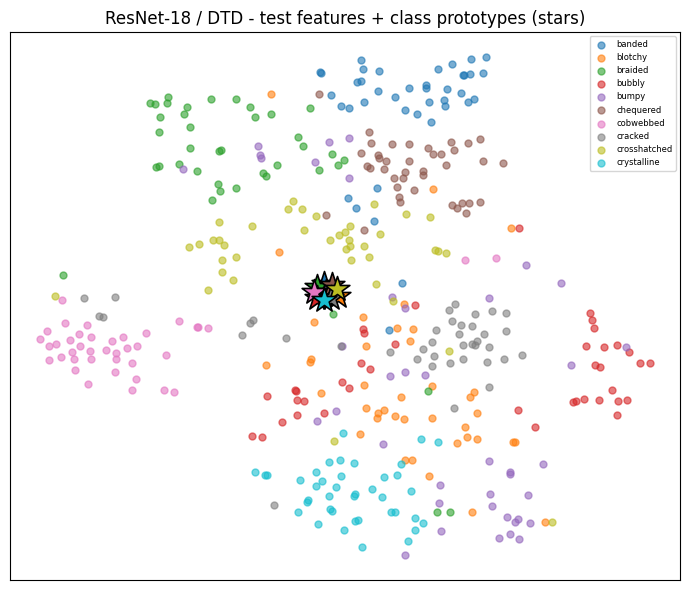

saved feature_viz_dtd.png


In [10]:
# DTD - ResNet-18 only
test_feats, test_labels, classes = load_features('resnet18', 'dtd', 'test')
protos = full_prototypes['resnet18_dtd']['prototypes']

fig, ax = plt.subplots(figsize=(7, 6))
plot_feature_viz(ax, test_feats, test_labels, protos, classes, SELECTED_CLASSES,
                  'ResNet-18 / DTD - test features + class prototypes (stars)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_ROOT, 'feature_viz_dtd.png'), dpi=150)
plt.show()
print('saved feature_viz_dtd.png')

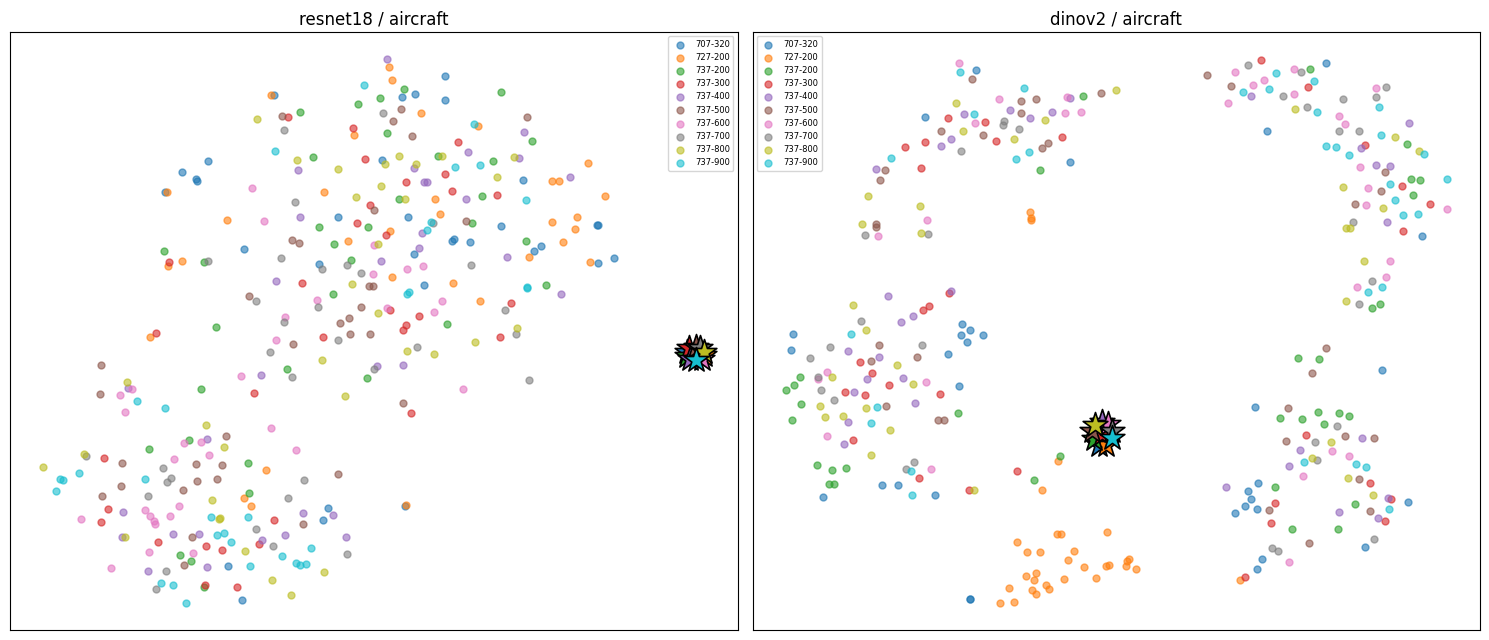

saved feature_viz_aircraft.png


In [11]:
# Aircraft - ResNet-18 vs DINOv2, same classes/images/colors for a fair comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, encoder in zip(axes, ['resnet18', 'dinov2']):
    test_feats, test_labels, classes = load_features(encoder, 'aircraft', 'test')
    protos = full_prototypes[f'{encoder}_aircraft']['prototypes']
    plot_feature_viz(ax, test_feats, test_labels, protos, classes, SELECTED_CLASSES,
                      f'{encoder} / aircraft')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_ROOT, 'feature_viz_aircraft.png'), dpi=150)
plt.show()
print('saved feature_viz_aircraft.png')

## Done - everything needed for the presentation is now in `figures/` and `results/`

Saved to your Drive:
- `results/final_accuracy_table.csv` - deliverable 1
- `figures/accuracy_vs_k.png` - deliverable 2
- `figures/loss_curves.png` - deliverable 3
- `figures/confusion_matrices.png` - deliverable 4
- `figures/feature_viz_dtd.png`, `figures/feature_viz_aircraft.png` - deliverable 5

**Before the presentation, actually look at these together and think through:**
- Does the DINOv2-vs-ResNet-18 gap on Aircraft (visible in the accuracy table and the
  accuracy-vs-K plot) match what the feature visualization *looks* like - do
  DINOv2's 10 classes look more visually separated than ResNet-18's for the same
  images?
- In the confusion matrices, are there specific classes that get confused with each
  other consistently? That's worth a sentence of discussion each - it's genuinely
  more convincing to say *why* two aircraft variants get mixed up than to just show
  the matrix and move on.
- In the loss curves, does the 10-shot setting show clear overfitting (train loss to
  ~0, val loss flat or rising)? If so, that's a direct answer to the assignment's
  question about whether "substantial overfitting occurs."
- Where do the prototype stars land relative to their class's point cloud in the
  feature-viz plots? If a star is off in an empty area away from its own cluster,
  that's a visual explanation for why the prototype method underperforms the linear
  probe on that dataset.